Mounted at /content/drive
Loading: /content/drive/MyDrive/EarthEngine_ML_Data/raw_merged_dataset.csv

--- Label distribution ---
Y
0    1080
1     480
Name: count, dtype: int64
Positive rate: 0.3076923076923077
Share Baseline_DSWE==0: 0.8666666666666667

After dropna: (1560, 10)

Sequence dataset: (1365, 14, 7) (1365,)
Seq positive rate: 0.3054945054945055

--- Split sizes ---
Train: (819, 14, 7) Val: (273, 14, 7) Test: (273, 14, 7)
Train pos rate: 0.3052503052503053 Val pos rate: 0.3076923076923077 Test pos rate: 0.304029304029304

GP training subset: (500, 98) pos_rate: 0.5

Training GP...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



Optimized kernel:
 6.15**2 * Matern(length_scale=8.03, nu=1.5) + WhiteKernel(noise_level=1e-05)

Best VAL threshold: 0.635 (Val F1: 0.8125)

--- Test metrics ---
PR-AUC: 0.868043996777463
ROC-AUC: 0.9284717818642994
Brier: 0.13102086102226743
F1 (VAL-threshold): 0.7402597402597403

Confusion matrix:
 [[176  14]
 [ 26  57]]

Classification report:
               precision    recall  f1-score   support

           0     0.8713    0.9263    0.8980       190
           1     0.8028    0.6867    0.7403        83

    accuracy                         0.8535       273
   macro avg     0.8371    0.8065    0.8191       273
weighted avg     0.8505    0.8535    0.8500       273


✅ Saved GP outputs to: /content/drive/MyDrive/EarthEngine_ML_Data/gp_seq_outputs_match_label_v1


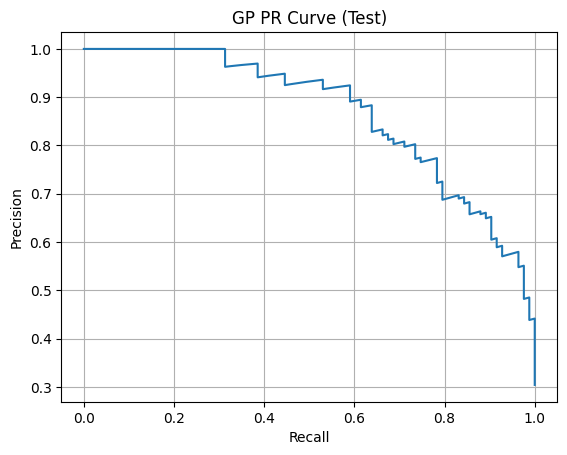

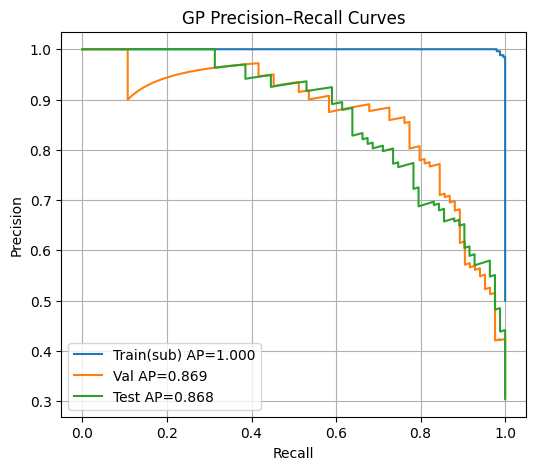

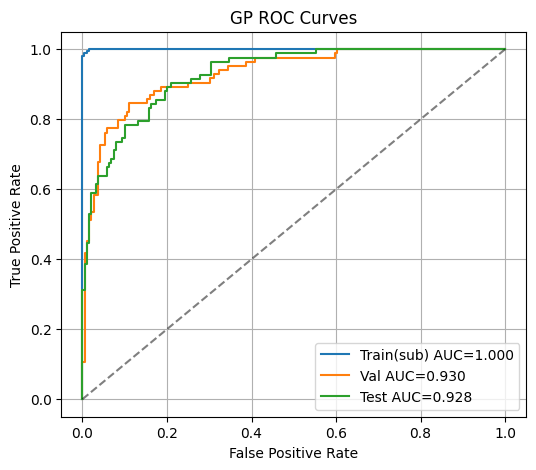

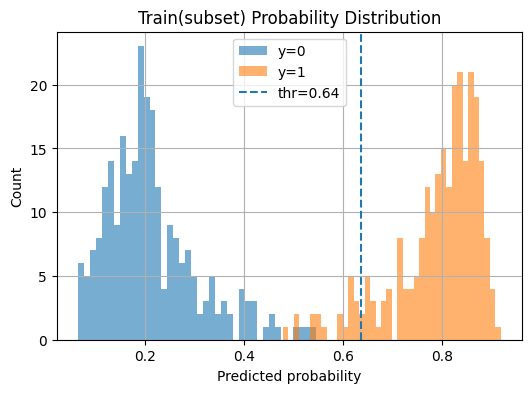

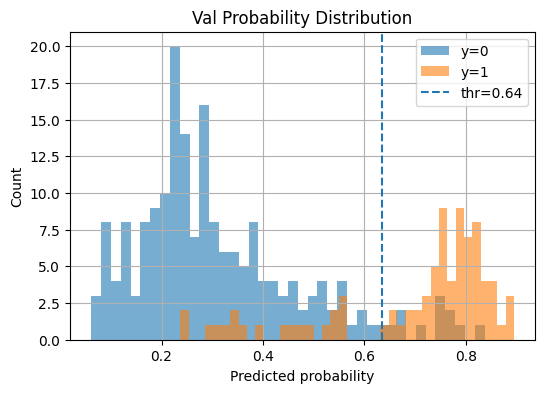

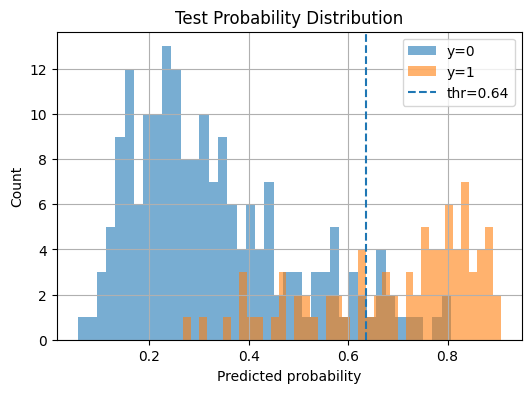

In [ ]:
# GP sequence classifier
# Label: DSWE_mean > (median(DSWE_mean) per Region_ID × 1.09), strict '>'

import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    f1_score, brier_score_loss
)
import joblib


# -----------------------------
# 1) Setup
# -----------------------------
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/EarthEngine_ML_Data"
INPUT_FILE = os.path.join(BASE_DIR, "raw_merged_dataset.csv")

OUT_DIR = os.path.join(BASE_DIR, "gp_seq_outputs_match_label_v1")
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42
SEQ_LEN = 14
RATIO = 1.09

REGION_COL = "Region_ID"
DATE_COL = "Date"
DSWE_COL = "DSWE_mean"

FEATURES = [
    "Precip_mm",
    "rain_sum_7", "rain_sum_15", "rain_sum_30", "rain_sum_60", "rain_sum_90",
    "rain_days_7",
]

# GP imbalance workaround: balanced subsample TRAIN ONLY (None = use full train set)
MAX_TRAIN_SAMPLES = 650


# -----------------------------
# 2) Load data
# -----------------------------
print(f"Loading: {INPUT_FILE}")
df = pd.read_csv(INPUT_FILE)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])


# -----------------------------
# 3) Build label
# -----------------------------
if DSWE_COL not in df.columns:
    raise ValueError("DSWE_mean not found in dataset")

df[DSWE_COL] = pd.to_numeric(df[DSWE_COL], errors="coerce")
df = df.dropna(subset=[DSWE_COL]).copy()

df["Baseline_DSWE"] = df.groupby(REGION_COL)[DSWE_COL].transform("median")
df["Y"] = (df[DSWE_COL] > (df["Baseline_DSWE"] * RATIO)).astype(int)

print("\n--- Label distribution ---")
print(df["Y"].value_counts())
print("Positive rate:", df["Y"].mean())
print("Share Baseline_DSWE==0:", (df["Baseline_DSWE"] == 0).mean())


# -----------------------------
# 4) Clean + sort
# -----------------------------
needed = [REGION_COL, DATE_COL, "Y"] + FEATURES
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_model = df[needed].dropna().copy()
df_model = df_model.sort_values([REGION_COL, DATE_COL])
print("\nAfter dropna:", df_model.shape)


# -----------------------------
# 5) Build sequences
# -----------------------------
def make_sequences(frame, features, label_col, date_col, region_col, seq_len):
    X_list, y_list = [], []
    for _, g in frame.groupby(region_col, sort=False):
        g = g.sort_values(date_col)
        Xv = g[features].to_numpy(dtype=np.float32)
        yv = g[label_col].to_numpy(dtype=np.int64)

        if len(g) < seq_len:
            continue

        for i in range(seq_len - 1, len(g)):
            X_list.append(Xv[i - seq_len + 1: i + 1])
            y_list.append(yv[i])  # label at end of window

    X = np.stack(X_list) if X_list else np.empty((0, seq_len, len(features)), dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    return X, y


X_seq, y_seq = make_sequences(df_model, FEATURES, "Y", DATE_COL, REGION_COL, SEQ_LEN)
print("\nSequence dataset:", X_seq.shape, y_seq.shape)
print("Seq positive rate:", y_seq.mean() if len(y_seq) else None)
if len(y_seq) == 0:
    raise ValueError("No sequences created. Check SEQ_LEN and time sorting.")


# -----------------------------
# 6) Train/val/test split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.40, random_state=RANDOM_STATE, stratify=y_seq
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("\n--- Split sizes ---")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train pos rate:", y_train.mean(), "Val pos rate:", y_val.mean(), "Test pos rate:", y_test.mean())


# -----------------------------
# 7) Flatten + standardize
# -----------------------------
def flatten(X):
    return X.reshape((X.shape[0], -1))


scaler = StandardScaler()
X_train_fs = scaler.fit_transform(flatten(X_train))
X_val_fs = scaler.transform(flatten(X_val))
X_test_fs = scaler.transform(flatten(X_test))


# -----------------------------
# 8) Balanced subsample for GP training (train only)
# -----------------------------
rng = np.random.default_rng(RANDOM_STATE)

pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

n_pos = len(pos_idx)
n_neg_keep = min(len(neg_idx), n_pos)  # 1:1 balance
neg_keep = rng.choice(neg_idx, size=n_neg_keep, replace=False)

keep_idx = np.concatenate([pos_idx, neg_keep])
rng.shuffle(keep_idx)

X_gp = X_train_fs[keep_idx]
y_gp = y_train[keep_idx]

if MAX_TRAIN_SAMPLES is not None and len(y_gp) > MAX_TRAIN_SAMPLES:
    sub = rng.choice(np.arange(len(y_gp)), size=MAX_TRAIN_SAMPLES, replace=False)
    X_gp, y_gp = X_gp[sub], y_gp[sub]

print("\nGP training subset:", X_gp.shape, "pos_rate:", y_gp.mean())


# -----------------------------
# 9) Train GP classifier
# -----------------------------
kernel = (
    ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale=1.0, nu=1.5)
    + WhiteKernel(noise_level=1e-3)
)

gp = GaussianProcessClassifier(
    kernel=kernel,
    random_state=RANDOM_STATE,
    max_iter_predict=100
)

print("\nTraining GP...")
gp.fit(X_gp, y_gp)

print("\nOptimized kernel:\n", gp.kernel_)


# -----------------------------
# 10) Tune threshold on validation set
# -----------------------------
val_proba = gp.predict_proba(X_val_fs)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, val_proba)

f1s = (2 * prec * rec) / np.maximum(prec + rec, 1e-12)
best_idx = int(np.nanargmax(f1s))
best_thr = thr[best_idx - 1] if best_idx > 0 and (best_idx - 1) < len(thr) else 0.5
best_f1_val = float(f1s[best_idx])

print(f"\nBest VAL threshold: {best_thr:.3f} (Val F1: {best_f1_val:.4f})")


# -----------------------------
# 11) Evaluate on test set
# -----------------------------
test_proba = gp.predict_proba(X_test_fs)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

pr_auc = float(average_precision_score(y_test, test_proba))
roc_auc = float(roc_auc_score(y_test, test_proba))
brier = float(brier_score_loss(y_test, test_proba))
f1 = float(f1_score(y_test, test_pred))

print("\n--- Test metrics ---")
print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc)
print("Brier:", brier)
print("F1 (VAL-threshold):", f1)
print("\nConfusion matrix:\n", confusion_matrix(y_test, test_pred))
print("\nClassification report:\n", classification_report(y_test, test_pred, digits=4))


# -----------------------------
# 12) Save artifacts (model + scaler + metrics)
# -----------------------------
joblib.dump(gp, os.path.join(OUT_DIR, "gp_seq_model.joblib"))
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.joblib"))

with open(os.path.join(OUT_DIR, "metrics.json"), "w") as f:
    json.dump(
        {
            "dswe_col": DSWE_COL,
            "ratio": RATIO,
            "best_val_threshold": float(best_thr),
            "val_best_f1": float(best_f1_val),
            "test_pr_auc": pr_auc,
            "test_roc_auc": roc_auc,
            "test_brier": brier,
            "test_f1": f1,
            "features": FEATURES,
            "seq_len": SEQ_LEN,
            "label_method": "per_region_median_times_ratio_strict_gt",
            "gp_train_subset_n": int(X_gp.shape[0]),
            "gp_train_subset_pos_rate": float(y_gp.mean()),
            "kernel_optimized": str(gp.kernel_),
        },
        f,
        indent=2,
    )

print(f"\n✅ Saved GP outputs to: {OUT_DIR}")


# -----------------------------
# 13) Plots
# -----------------------------
# PR curve (test)
p_t, r_t, _ = precision_recall_curve(y_test, test_proba)
plt.figure()
plt.plot(r_t, p_t)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("GP PR Curve (Test)")
plt.grid(True)
plt.show()

# PR curves (train subset / val / test)
plt.figure(figsize=(6, 5))
train_proba = gp.predict_proba(X_gp)[:, 1]
for name, yt, pb in [
    ("Train(sub)", y_gp, train_proba),
    ("Val", y_val, val_proba),
    ("Test", y_test, test_proba),
]:
    p, r, _ = precision_recall_curve(yt, pb)
    ap = average_precision_score(yt, pb)
    plt.plot(r, p, label=f"{name} AP={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("GP Precision–Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

# ROC curves
plt.figure(figsize=(6, 5))
for name, yt, pb in [
    ("Train(sub)", y_gp, train_proba),
    ("Val", y_val, val_proba),
    ("Test", y_test, test_proba),
]:
    fpr, tpr, _ = roc_curve(yt, pb)
    auc = roc_auc_score(yt, pb)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GP ROC Curves")
plt.legend()
plt.grid(True)
plt.show()


def plot_prob_hist(y, proba, title):
    plt.figure(figsize=(6, 4))
    plt.hist(proba[y == 0], bins=40, alpha=0.6, label="y=0")
    plt.hist(proba[y == 1], bins=40, alpha=0.6, label="y=1")
    plt.axvline(best_thr, linestyle="--", label=f"thr={best_thr:.2f}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_prob_hist(y_gp, train_proba, "Train(subset) Probability Distribution")
plot_prob_hist(y_val, val_proba, "Val Probability Distribution")
plot_prob_hist(y_test, test_proba, "Test Probability Distribution")
